In [9]:
import xarray as xr
ukesm = xr.open_dataset('ROMS_UKESM_HS_FF.nc')
cnrm = xr.open_dataset('ROMS_CNRM_HS_FF.nc')
gfdl = xr.open_dataset('ROMS_GFDL_HS_FF.nc')
gfdl.dims, cnrm.dims, ukesm.dims

(FrozenMappingWarningOnValuesAccess({'TIME': 1438, 'LAT_RHO': 757, 'LON_RHO': 1081}),
 FrozenMappingWarningOnValuesAccess({'TIME': 1438, 'LAT_RHO': 757, 'LON_RHO': 1081}),
 FrozenMappingWarningOnValuesAccess({'TIME': 1438, 'LAT_RHO': 757, 'LON_RHO': 1081}))

In [11]:
ukesm_bob = ukesm.sel(
    LAT_RHO=slice(0, 25),
    LON_RHO=slice(77, 102)
)

cnrm_bob = cnrm.sel(
    LAT_RHO=slice(0, 25),
    LON_RHO=slice(77, 102)
)

gfdl_bob = gfdl.sel(
    LAT_RHO=slice(0, 25),
    LON_RHO=slice(77, 102)
)

# --------------------------------------------------
# 2. Create ensemble dimension
# --------------------------------------------------

ensemble = xr.concat(
    [ukesm_bob, cnrm_bob, gfdl_bob],
    dim='MODEL'
)

# Give model names
ensemble = ensemble.assign_coords(
    MODEL=['UKESM', 'CNRM', 'GFDL']
)

print(ensemble)

<xarray.Dataset> Size: 2GB
Dimensions:  (MODEL: 3, TIME: 1438, LAT_RHO: 310, LON_RHO: 301)
Coordinates:
  * MODEL    (MODEL) <U5 60B 'UKESM' 'CNRM' 'GFDL'
  * TIME     (TIME) datetime64[ns] 12kB 1980-01-16T17:15:00 ... 2100-10-17T15...
  * LAT_RHO  (LAT_RHO) float32 1kB 0.02108 0.1044 0.1877 ... 24.8 24.87 24.95
  * LON_RHO  (LON_RHO) float32 1kB 77.0 77.08 77.17 77.25 ... 101.8 101.9 102.0
Data variables:
    pCO2     (MODEL, TIME, LAT_RHO, LON_RHO) float32 2GB 361.7 361.7 ... nan nan


In [12]:
ensemble_mean = ensemble.mean(dim='MODEL')

print(ensemble_mean)

<xarray.Dataset> Size: 537MB
Dimensions:  (TIME: 1438, LAT_RHO: 310, LON_RHO: 301)
Coordinates:
  * TIME     (TIME) datetime64[ns] 12kB 1980-01-16T17:15:00 ... 2100-10-17T15...
  * LAT_RHO  (LAT_RHO) float32 1kB 0.02108 0.1044 0.1877 ... 24.8 24.87 24.95
  * LON_RHO  (LON_RHO) float32 1kB 77.0 77.08 77.17 77.25 ... 101.8 101.9 102.0
Data variables:
    pCO2     (TIME, LAT_RHO, LON_RHO) float32 537MB 370.8 370.8 ... nan nan


In [13]:
ensemble_mean.to_netcdf('ROMS_ENSEMBLE_BoB_HS_FF.nc')

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


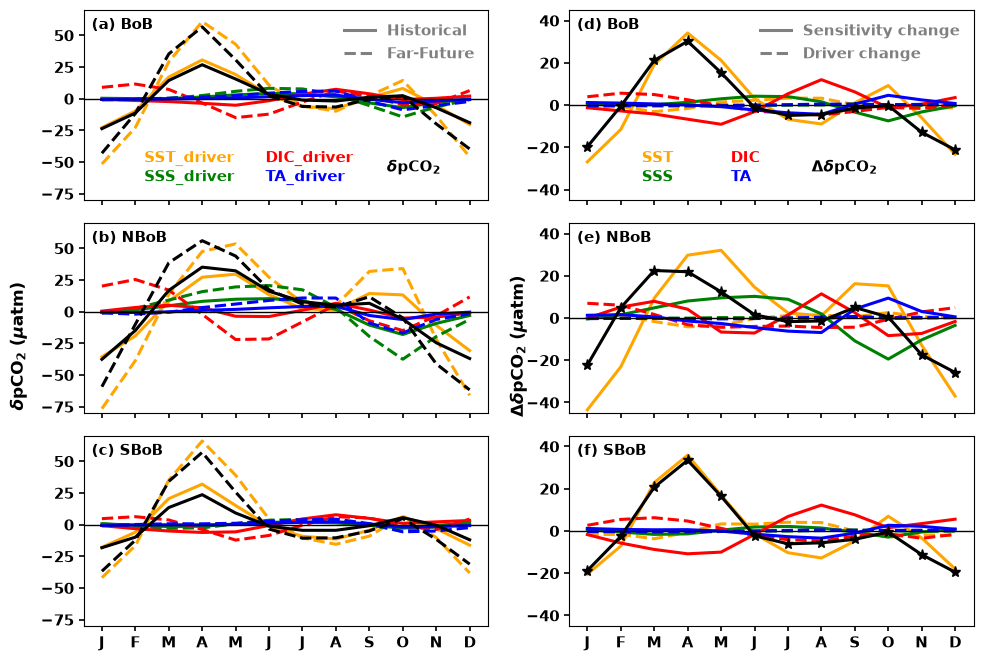

In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1. OPEN THE TWO NETCDF FILES
# ============================================================

sea_driv = xr.open_dataset("Seasonal_drivers_HS_FF_final.nc")
sea_amp = xr.open_dataset("Seasonal_amplification_HS_FF_final.nc")

# ============================================================
# 2. SETTINGS
# ============================================================

regions = ["BoB", "NBoB", "SBoB"]

left_titles = [
    "(a) BoB",
    "(b) NBoB",
    "(c) SBoB"
]

right_titles = [
    "(d) BoB",
    "(e) NBoB",
    "(f) SBoB"
]

months = np.arange(1, 13)

month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
# month_labels = [
#     "Jan", "Feb", "Mar", "Apr", "May", "Jun",
#     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
# ]

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

colors = {
    "SST": "orange",
    "SSS": "green",
    "DIC": "red",
    "TA": "blue",
    "pCO2": "black"
}s

# ============================================================
# 3. MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

# ============================================================
# 4. CREATE 3 × 2 FIGURE
# ============================================================

fig, axs = plt.subplots(
    3, 2,
    figsize=(10, 7),
    sharex="col"
)

# ============================================================
# 5. LEFT COLUMN
#    Historical = solid
#    Far-Future = dashed
# ============================================================

parameters_left = ["SST", "SSS", "DIC", "TA", "δpCO₂"]

for i, (region, title) in enumerate(zip(regions, left_titles)):

    ax = axs[i, 0]

    for parameter in parameters_left:

        # ----------------------------------------------------
        # Historical
        # ----------------------------------------------------
        hist = sea_driv["delta_pCO2_driver"].sel(
            period="Historical",
            region=region,
            parameter=parameter
        ).values

        # ----------------------------------------------------
        # Far-Future
        # ----------------------------------------------------
        future = sea_driv["delta_pCO2_driver"].sel(
            period="Far-Future",
            region=region,
            parameter=parameter
        ).values

        # ----------------------------------------------------
        # Historical = solid
        # ----------------------------------------------------
        ax.plot(
            months,
            hist,
            color=colors[parameter if parameter != "δpCO₂" else "pCO2"],
            lw=2.2,
            ls="-"
        )

        # ----------------------------------------------------
        # Far-Future = dashed
        # ----------------------------------------------------
        ax.plot(
            months,
            future,
            color=colors[parameter if parameter != "δpCO₂" else "pCO2"],
            lw=2.2,
            ls="--"
        )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1
    )

    # Panel label
    ax.text(
        0.02,
        0.90,
        title,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Y-axis range
    # --------------------------------------------------------
    ax.set_ylim(-80, 70)
    ax.set_yticks([-75, -50, -25, 0, 25, 50])

    # Tick properties
    ax.tick_params(
        width=1.2,
        labelsize=11
    )

    # Hide x labels except bottom
    if i < 2:
        ax.tick_params(labelbottom=False)

# ============================================================
# 6. LEFT PANEL ANNOTATIONS
# ============================================================

ax = axs[0, 0]

ax.text(
    0.15, 0.20,
    "SST_driver",s
    color="orange",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.15, 0.10,
    "SSS_driver",
    color="green",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.45, 0.20,
    "DIC_driver",
    color="red",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.45, 0.10,
    "TA_driver",
    color="blue",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.75, 0.15,
    r"$\delta$pCO$_2$",
    color="black",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

# ============================================================
# 7. HISTORICAL / FAR-FUTURE LEGEND
# ============================================================

style_legend = [
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="-",
        label="Historical"
    ),
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="--",
        label="Far-Future"
    )
]

axs[0, 0].legend(
    handles=style_legend,
    loc="upper right",
    fontsize=11,
    framealpha=0,
    labelcolor="gray"
)

# ============================================================
# 8. RIGHT COLUMN
#
# Solid  = Sensitivity change
# Dashed = Driver change
# Black stars = ΔδpCO2
# ============================================================

for i, (region, title) in enumerate(zip(regions, right_titles)):

    ax = axs[i, 1]

    # --------------------------------------------------------
    # SST
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_sst"].sel(region=region).values,
        color="orange",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["sdrv_sst"].sel(region=region).values,
        color="orange",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # SSS
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_sss"].sel(region=region).values,
        color="green",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["drv_sss"].sel(region=region).values,
        color="green",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # DIC
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_dic"].sel(region=region).values,
        color="red",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["drv_dic"].sel(region=region).values,
        color="red",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # TA
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_alk"].sel(region=region).values,
        color="blue",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["drv_alk"].sel(region=region).values,
        color="blue",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # ΔδpCO2
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["delta_delpCO2"].sel(region=region).values,
        color="black",
        lw=2.2,
        marker="*",
        markersize=8
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1
    )

    # Panel label
    ax.text(
        0.02,
        0.90,
        title,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Right-panel y-axis
    # --------------------------------------------------------
    ax.set_ylim(-45, 45)
    ax.set_yticks(
        [-40, -20, 0, 20, 40]
    )

    ax.tick_params(
        width=1.2,
        labelsize=11
    )

    # Hide x labels except bottom
    if i < 2:
        ax.tick_params(labelbottom=False)

# ============================================================
# 9. RIGHT PANEL ANNOTATIONS
# ============================================================

ax = axs[0, 1]

ax.text(
    0.18, 0.20,
    "SST",
    color="orange",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.18, 0.10,
    "SSS",
    color="green",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.40, 0.20,
    "DIC",
    color="red",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.40, 0.10,
    "TA",
    color="blue",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.60, 0.15,
    r"$\Delta\delta$pCO$_2$",
    color="black",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

# ============================================================
# 10. RIGHT PANEL LEGEND
# ============================================================

right_legend = [
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="-",
        label="Sensitivity change"
    ),
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="--",
        label="Driver change"
    )
]

axs[0, 1].legend(
    handles=right_legend,
    loc="upper right",
    fontsize=11,
    framealpha=0,
    labelcolor="gray"
)

# ============================================================
# 11. X AXIS
# ============================================================

for j in range(2):

    axs[2, j].set_xticks(months)

    axs[2, j].set_xticklabels(
        month_labels,
        rotation=0,
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# 12. COMMON Y-AXIS LABELS
#     ONLY ONE LABEL FOR EACH COLUMN
# ============================================================

fig.text(
    0.025,
    0.50,
    r"$\delta$pCO$_2$ ($\mu$atm)",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=12,
    fontweight="bold"
)

fig.text(
    0.525,
    0.50,
    r"$\Delta\delta$pCO$_2$ ($\mu$atm)",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=12,
    fontweight="bold"
)

# ============================================================
# 13. REMOVE INDIVIDUAL Y LABELS
# ============================================================

for i in range(3):
    axs[i, 0].set_ylabel("")
    axs[i, 1].set_ylabel("")

# ============================================================
# 14. SPINES / APPEARANCE
# ============================================================

for ax in axs.flat:

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    ax.tick_params(
        axis="both",
        which="major",
        width=1.2
    )

# ============================================================
# 15. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.10,
    top=0.98,
    wspace=0.20,
    hspace=0.12
)

# ============================================================
# 16. SAVE
# ============================================================

# outfile = ("Seasonal_drivers_ampl_HS_FF_combine.png")
# plt.savefig(outfile, dpi=600, bbox_inches="tight")

plt.show()

In [15]:
sea_amp

<xarray.Dataset> Size: 3kB
Dimensions:        (region: 3, month: 12)
Coordinates:
  * region         (region) <U4 48B 'BoB' 'NBoB' 'SBoB'
  * month          (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    month_name     (month) <U3 144B ...
Data variables:
    sens_sst       (region, month) float64 288B ...
    drv_sst        (region, month) float64 288B ...
    sens_sss       (region, month) float64 288B ...
    drv_sss        (region, month) float64 288B ...
    sens_dic       (region, month) float64 288B ...
    drv_dic        (region, month) float64 288B ...
    sens_alk       (region, month) float64 288B ...
    drv_alk        (region, month) float64 288B ...
    hist_delpCO2   (region, month) float64 288B ...
    fut_delpCO2    (region, month) float64 288B ...
    delta_delpCO2  (region, month) float64 288B ...
Attributes:
    title:              Seasonal pCO2 sensitivity and driver changes
    description:        Data used to generate the seasonal pCO2 sensitivity/d...
    historical_period:  1985-2014
    far_future_period:  2071-2100
    regions:            Bay of Bengal (BoB), Northern Bay of Bengal (NBoB), S...
    source:             CROCO-PISCES regional pCO2 analysis
    created:            September 2026

[ 4.57764721  8.41157799  4.00288916  0.90848998  0.2107273  -2.46386615
 -3.20634    -3.77177586 -3.90003538 -3.09859388 -3.89142468 -0.99489322]
[ 13.26033062  12.64318245   0.09518641 -10.95353208 -11.75942371
  -7.3004569   -5.43755978  -5.96642159  -4.81822421   1.91994538
   6.29328996  10.0796685 ]
[ 1.3245321   6.81255239  5.43086069  5.54971898  5.00870796 -0.49676443
 -2.26559005 -2.88726678 -3.52005517 -4.98652561 -7.81467769 -5.20191108]


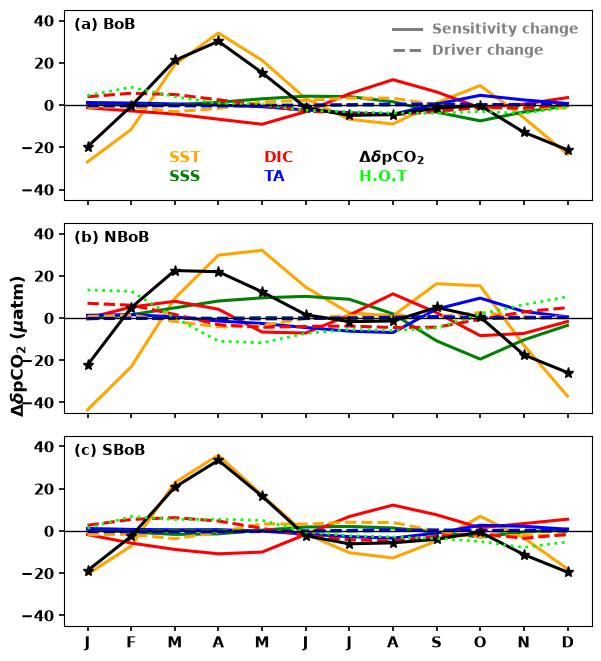

In [46]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1. OPEN FILE
# ============================================================

sea_amp = xr.open_dataset("Seasonal_amplification_HS_FF_final.nc")

# ============================================================
# 2. SETTINGS
# ============================================================

regions = ["BoB", "NBoB", "SBoB"]

right_titles = [
    "(a) BoB",
    "(b) NBoB",
    "(c) SBoB"
]

months = np.arange(1, 13)

month_labels = [
    "J", "F", "M", "A", "M", "J",
    "J", "A", "S", "O", "N", "D"
]

colors = {
    "SST": "orange",
    "SSS": "green",
    "DIC": "red",
    "TA": "blue"
}

plt.rcParams.update({
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

# ============================================================
# 3. CREATE ONLY RIGHT COLUMN
# ============================================================

fig, axs = plt.subplots(
    3, 1,
    figsize=(6, 7),
    sharex=True
)

# ============================================================
# 4. RIGHT PANELS
# ============================================================

for i, (region, title) in enumerate(zip(regions, right_titles)):

    ax = axs[i]

    # --------------------------------------------------------
    # Extract sensitivity changes
    # --------------------------------------------------------

    sens_sst = sea_amp["sens_sst"].sel(region=region).values
    sens_sss = sea_amp["sens_sss"].sel(region=region).values
    sens_dic = sea_amp["sens_dic"].sel(region=region).values
    sens_ta  = sea_amp["sens_alk"].sel(region=region).values

    # --------------------------------------------------------
    # Extract driver changes
    # --------------------------------------------------------

    drv_sst = sea_amp["drv_sst"].sel(region=region).values
    drv_sss = sea_amp["drv_sss"].sel(region=region).values
    drv_dic = sea_amp["drv_dic"].sel(region=region).values
    drv_ta  = sea_amp["drv_alk"].sel(region=region).values

    # --------------------------------------------------------
    # ΔδpCO2
    # --------------------------------------------------------

    delta_delpCO2 = sea_amp["delta_delpCO2"].sel(
        region=region
    ).values

    # ========================================================
    # 5. CALCULATE SUM OF ALL FOUR DRIVERS
    # ========================================================

    sum_drivers = (
        drv_sst +
        drv_sss +
        drv_dic +
        drv_ta +
        sens_sst +
        sens_sss +
        sens_dic +
        sens_ta
    )

    # ========================================================
    # 6. DIFFERENCE / RESIDUAL
    # ========================================================

    difference = delta_delpCO2 - sum_drivers
    print(difference)

    # ========================================================
    # 7. SENSITIVITY CHANGE
    #     Solid lines
    # ========================================================

    ax.plot(
        months,
        sens_sst,
        color=colors["SST"],
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sens_sss,
        color=colors["SSS"],
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sens_dic,
        color=colors["DIC"],
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sens_ta,
        color=colors["TA"],
        lw=2.2,
        ls="-"
    )

    # ========================================================
    # 8. DRIVER CHANGE
    #     Dashed lines
    # ========================================================

    ax.plot(
        months,
        drv_sst,
        color=colors["SST"],
        lw=2.2,
        ls="--"
    )

    ax.plot(
        months,
        drv_sss,
        color=colors["SSS"],
        lw=2.2,
        ls="--"
    )

    ax.plot(
        months,
        drv_dic,
        color=colors["DIC"],
        lw=2.2,
        ls="--"
    )

    ax.plot(
        months,
        drv_ta,
        color=colors["TA"],
        lw=2.2,
        ls="--"
    )

    # ========================================================
    # 9. ΔδpCO2
    #     Black stars
    # ========================================================

    ax.plot(
        months,
        delta_delpCO2,
        color="black",
        lw=2.2,
        marker="*",
        markersize=8,
        label=r"$\Delta\delta$pCO$_2$"
    )

    # ========================================================
    # 10. DIFFERENCE
    #     ΔδpCO2 - sum of all drivers
    #     Dotted black line
    # ========================================================

    ax.plot(
        months,
        difference,
        color="lime",
        lw=2.0,
        ls=":"
    )

    # ========================================================
    # 11. ZERO LINE
    # ========================================================

    ax.axhline(
        0,
        color="black",
        lw=1
    )

    # ========================================================
    # 12. PANEL LABEL
    # ========================================================

    ax.text(
        0.02,
        0.90,
        title,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # ========================================================
    # 13. Y AXIS
    # ========================================================

    ax.set_ylim(-45, 45)

    ax.set_yticks(
        [-40, -20, 0, 20, 40]
    )

    ax.tick_params(
        width=1.2,
        labelsize=11
    )

# ============================================================
# 14. ANNOTATIONS
# ============================================================

axs[0].text(
    0.20, 0.20,
    "SST",
    color="orange",
    transform=axs[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

axs[0].text(
    0.20, 0.10,
    "SSS",
    color="green",
    transform=axs[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

axs[0].text(
    0.38, 0.20,
    "DIC",
    color="red",
    transform=axs[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

axs[0].text(
    0.38, 0.10,
    "TA",
    color="blue",
    transform=axs[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

axs[0].text(
    0.56, 0.20,
    r"$\Delta\delta$pCO$_2$",
    color="black",
    transform=axs[0].transAxes,
    fontsize=11,
    fontweight="bold"
)
axs[0].text(
    0.56, 0.10,
    "H.O.T",
    color="lime",
    transform=axs[0].transAxes,
    fontsize=11,
    fontweight="bold"
)
   

# ============================================================
# 15. LEGEND
# ============================================================

right_legend = [

    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="-",
        label="Sensitivity change"
    ),

    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="--",
        label="Driver change"
    )
]

axs[0].legend(
    handles=right_legend,
    loc="upper right",
    fontsize=10,
    framealpha=0,
    labelcolor="gray"
)

# ============================================================
# 16. X AXIS
# ============================================================-7.81467769

axs[2].set_xticks(months)

axs[2].set_xticklabels(
    month_labels,
    rotation=0,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

# ============================================================
# 17. COMMON Y LABEL
# ============================================================

fig.text(
    0.025,
    0.50,
    r"$\Delta\delta$pCO$_2$ ($\mu$atm)",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=12,
    fontweight="bold"
)

# ============================================================
# 18. SPINES
# ============================================================

for ax in axs:

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    ax.tick_params(
        axis="both",
        which="major",
        width=1.2
    )

# ============================================================
# 19. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.10,
    top=0.98,
    hspace=0.12
)

# ============================================================
# 20. SAVE
# ============================================================

plt.savefig(
    "Seasonal_amplification_right_panel_with_difference.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

array([-18.78128671,  -2.57203014,  20.68997824,  33.45265413,
        16.44475805,  -2.27109752,  -6.10965729,  -5.6229912 ,
        -3.96467064,  -0.56836524, -11.19451954, -19.50277213])

In [22]:
difference

array([ 1.3245321 ,  6.81255239,  5.43086069,  5.54971898,  5.00870796,
       -0.49676443, -2.26559005, -2.88726678, -3.52005517, -4.98652561,
       -7.81467769, -5.20191108])

In [ ]:
 BoB
     [4.57764721  8.41157799  4.00288916  0.90848998  0.2107273  -2.46386615
 -3.20634    -3.77177586 -3.90003538 -3.09859388 -3.89142468 -0.99489322]

NBoB
    [ 13.26033062  12.64318245   0.09518641 -10.95353208 -11.75942371
  -7.3004569   -5.43755978  -5.96642159  -4.81822421   1.91994538
   6.29328996  10.0796685 ]

SBOB
    [ 1.3245321   6.81255239  5.43086069  5.54971898  5.00870796 -0.49676443
 -2.26559005 -2.88726678 -3.52005517 -4.98652561 -7.81467769 -5.20191108]

In [47]:
import xarray as xr
pco2 = xr.open_dataset('BoB_pCO2_Sur_80_14.nc')
pco2


<xarray.Dataset> Size: 276MB
Dimensions:         (TIME: 418, LAT_RHO379_689: 311, LON_RHO577_841: 265)
Coordinates:
  * TIME            (TIME) datetime64[ns] 3kB 1980-01-16T17:15:00 ... 2014-10...
  * LAT_RHO379_689  (LAT_RHO379_689) float32 1kB 0.02108 0.1044 ... 24.95 25.02
  * LON_RHO577_841  (LON_RHO577_841) float32 1kB 78.0 78.08 ... 99.92 100.0
Data variables:
    pCO2            (TIME, LAT_RHO379_689, LON_RHO577_841) float64 276MB ...

In [51]:
import xarray as xr

# Open dataset
pco2 = xr.open_dataset('BoB_Temp_Sur_80_14.nc')

# Monthly climatology: mean for each calendar month
pco2_clim = pco2.groupby('TIME.month').mean(dim='TIME', skipna=True)

# Save to NetCDF
pco2_clim.to_netcdf('BoB_SST_1980_2014.nc')

print(pco2_clim)

<xarray.Dataset> Size: 8MB
Dimensions:              (month: 12, LAT_RHO379_689: 311, bnds: 2, DEPTH1_1: 1,
                          LON_RHO577_841: 265)
Coordinates:
  * month                (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * LAT_RHO379_689       (LAT_RHO379_689) float32 1kB 0.02108 0.1044 ... 25.02
  * DEPTH1_1             (DEPTH1_1) float32 4B -0.0
  * LON_RHO577_841       (LON_RHO577_841) float32 1kB 78.0 78.08 ... 99.92 100.0
Dimensions without coordinates: bnds
Data variables:
    LAT_RHO379_689_bnds  (month, LAT_RHO379_689, bnds) float32 30kB -0.02059 ...
    DEPTH1_1_bnds        (month, DEPTH1_1, bnds) float32 96B -2.5 2.5 ... 2.5
    TEMP                 (month, DEPTH1_1, LAT_RHO379_689, LON_RHO577_841) float64 8MB ...
Attributes:
    history:      FERRET V7.3 (optimized) 17-Apr-25
    Conventions:  CF-1.6


/tmp/ipykernel_11850/880245700.py:10: UserWarning: Unlimited dimension(s) {'TIME'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'TIME'} from 'dataset.encoding'.
  pco2_clim.to_netcdf('BoB_SST_1980_2014.nc')


In [54]:
import xarray as xr
sea_driv = xr.open_dataset("Seasonal_drivers_HS_FF_final.nc")
sea_driv

<xarray.Dataset> Size: 2kB
Dimensions:            (period: 2, region: 3, parameter: 5, month: 12)
Coordinates:
  * period             (period) <U10 80B 'Historical' 'Far-Future'
  * region             (region) <U4 48B 'BoB' 'NBoB' 'SBoB'
  * parameter          (parameter) <U5 100B 'SST' 'SSS' 'DIC' 'TA' 'δpCO₂'
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    month_name         (month) <U3 144B ...
Data variables:
    delta_pCO2_driver  (period, region, parameter, month) float32 1kB ...
Attributes:
    description:  Seasonal pCO2 driver contributions for Historical (1985-201...
    regions:      BoB: 5-25N, 78-100E; NBoB: 15-25N, 78-100E; SBoB: 5-15N, 78...
    parameters:   SST, SSS, DIC, TA and delta pCO2
    source:       CROCO-PISCES pCO2 driver analysis

In [55]:
# Select δpCO₂
delpCO2 = sea_driv.sel(parameter='δpCO₂')

print(delpCO2)

<xarray.Dataset> Size: 676B
Dimensions:            (period: 2, region: 3, month: 12)
Coordinates:
  * period             (period) <U10 80B 'Historical' 'Far-Future'
  * region             (region) <U4 48B 'BoB' 'NBoB' 'SBoB'
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    month_name         (month) <U3 144B ...
    parameter          <U5 20B 'δpCO₂'
Data variables:
    delta_pCO2_driver  (period, region, month) float32 288B ...
Attributes:
    description:  Seasonal pCO2 driver contributions for Historical (1985-201...
    regions:      BoB: 5-25N, 78-100E; NBoB: 15-25N, 78-100E; SBoB: 5-15N, 78...
    parameters:   SST, SSS, DIC, TA and delta pCO2
    source:       CROCO-PISCES pCO2 driver analysis


In [56]:
df = delpCO2['delta_pCO2_driver'].to_dataframe().reset_index()

print(df)

        period region  month parameter month_name  delta_pCO2_driver
0   Historical    BoB      1     δpCO₂        Jan         -23.596485
1   Historical    BoB      2     δpCO₂        Feb         -11.303761
2   Historical    BoB      3     δpCO₂        Mar          14.376817
3   Historical    BoB      4     δpCO₂        Apr          26.800507
4   Historical    BoB      5     δpCO₂        May          15.543568
..         ...    ...    ...       ...        ...                ...
67  Far-Future   SBoB      8     δpCO₂        Aug         -10.419916
68  Far-Future   SBoB      9     δpCO₂        Sep          -5.007088
69  Far-Future   SBoB     10     δpCO₂        Oct           4.809857
70  Far-Future   SBoB     11     δpCO₂        Nov         -11.635477
71  Far-Future   SBoB     12     δpCO₂        Dec         -31.181427

[72 rows x 6 columns]


In [57]:
for period in sea_driv.period.values:
    for region in sea_driv.region.values:
        values = sea_driv['delta_pCO2_driver'].sel(
            period=period,
            region=region,
            parameter='δpCO₂'
        )

        print(f"\n{period} - {region}")
        print(values.values)


Historical - BoB
[-23.596485  -11.3037615  14.376817   26.800507   15.543568    3.5802028
  -1.0737298  -1.8264992   1.1985645   2.3385882  -7.131871  -18.905901 ]

Historical - NBoB
[-37.59821   -14.872178   16.769659   35.137314   32.20844    16.10227
   7.874204    5.1316795   6.5923395  -5.8498993 -24.529667  -36.96595  ]

Historical - SBoB
[-18.22164     -9.933953    13.458276    23.600256     9.146422
  -1.226645    -4.5085745   -4.497536    -0.87194467   5.481904
  -0.45337668 -11.973187  ]

Far-Future - BoB
[-42.99395    -11.638054    35.324913    56.721333    30.68581
   2.253849    -6.1090493   -6.52888     -0.35310447   2.111125
 -19.82966    -39.644333  ]

Far-Future - NBoB
[-59.212566   -9.987645   38.52777    55.997875   43.879906   17.302803
   5.899357    3.6074526  11.770742   -4.9191995 -41.1759    -61.6906   ]

Far-Future - SBoB
[-36.768105  -12.271597   34.095432   56.999046   25.62099    -3.5229952
 -10.718718  -10.419916   -5.0070877   4.809857  -11.635477  -31.1